In [30]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import TransformedTargetRegressor
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    GroupShuffleSplit,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import (
    DecisionTreeRegressor,
    plot_tree,
)


# Configuration


In [31]:
DATASET_PATH = Path("datasets/45V-400mV_ml/ml_dataset.csv")

TARGET_COLUMN = "target_led_residual_ps"

# First model to inspect.
MAX_DEPTH = 4

# Depths tested in the complexity scan.
DEPTH_VALUES = list(range(1, 21))

TEST_SIZE = 0.25
RANDOM_STATE = 42

# Number of features shown in importance plots.
TOP_N_FEATURES = 20

# Number of permutations for test-set permutation importance.
N_PERMUTATION_REPEATS = 30

In [32]:
df = pd.read_csv(DATASET_PATH)

print(f"Rows:    {len(df):,}")
print(f"Columns: {df.shape[1]}")

display(df.head())

Rows:    6,736
Columns: 32


,meta_event_index,meta_event_id,meta_source_file_id,target_led_residual_ps,energy_ch1_max_amplitude_mV,energy_ch1_noise_rms_mV,energy_ch1_rise_t05_to_t50_ps,energy_ch1_t05_minus_timing_ch3_led_ps,energy_ch1_t50_minus_timing_ch3_led_ps,energy_ch2_max_amplitude_mV,...,timing_ch3_poly_rmse_mV,timing_ch4_max_amplitude_mV,timing_ch4_noise_rms_mV,timing_ch4_poly_c0,timing_ch4_poly_c1,timing_ch4_poly_c2,timing_ch4_poly_c3,timing_ch4_poly_c4,timing_ch4_poly_r2,timing_ch4_poly_rmse_mV
0,3,3,3;3;3;3,-25289.103851,465.461143,1.465668,8987.128023,26629.324569,35616.452592,463.457399,...,9.555734,166.188344,1.422668,62.028215,202.054591,54.122539,-155.213474,-52.704776,0.879819,24.898412
1,4,4,4;4;4;4,132.285149,467.967733,1.463304,9071.905971,1276.969526,10348.875497,468.488346,...,24.877812,161.591816,1.061181,62.652498,203.876018,49.673971,-158.295746,-46.786566,0.880906,24.818054
2,12,12,12;12;12;12,-14103.365851,458.416554,1.542146,8065.412185,15545.974760,23611.386945,466.568920,...,19.235305,161.844335,1.227801,62.452779,204.360353,50.510792,-159.069144,-47.182134,0.877860,25.199579
3,14,14,14;14;14;14,140.134149,457.993031,1.493385,8821.104783,1359.794081,10180.898864,471.261134,...,25.138521,161.778077,1.009525,62.563829,204.492411,50.890163,-159.526935,-47.645226,0.877260,25.251350
4,19,19,19;19;19;19,124.639149,462.603425,1.528071,9287.116679,1313.177941,10600.294620,464.298695,...,24.938021,162.084824,1.232555,62.442362,204.629867,53.056775,-160.139901,-49.219215,0.877934,25.145325


In [33]:
print("Column names:")
for column in df.columns:
    print(column)

Column names:
meta_event_index
meta_event_id
meta_source_file_id
target_led_residual_ps
energy_ch1_max_amplitude_mV
energy_ch1_noise_rms_mV
energy_ch1_rise_t05_to_t50_ps
energy_ch1_t05_minus_timing_ch3_led_ps
energy_ch1_t50_minus_timing_ch3_led_ps
energy_ch2_max_amplitude_mV
energy_ch2_noise_rms_mV
energy_ch2_rise_t05_to_t50_ps
energy_ch2_t05_minus_timing_ch4_led_ps
energy_ch2_t50_minus_timing_ch4_led_ps
timing_ch3_max_amplitude_mV
timing_ch3_noise_rms_mV
timing_ch3_poly_c0
timing_ch3_poly_c1
timing_ch3_poly_c2
timing_ch3_poly_c3
timing_ch3_poly_c4
timing_ch3_poly_r2
timing_ch3_poly_rmse_mV
timing_ch4_max_amplitude_mV
timing_ch4_noise_rms_mV
timing_ch4_poly_c0
timing_ch4_poly_c1
timing_ch4_poly_c2
timing_ch4_poly_c3
timing_ch4_poly_c4
timing_ch4_poly_r2
timing_ch4_poly_rmse_mV


In [34]:
metadata_columns = [
    column for column in df.columns
    if column.startswith("meta_")
]

excluded_columns = metadata_columns + [TARGET_COLUMN]

feature_columns = [
    column for column in df.columns
    if column not in excluded_columns
    and pd.api.types.is_numeric_dtype(df[column])
]

print(f"Metadata columns: {metadata_columns}")
print(f"Target column:    {TARGET_COLUMN}")
print(f"Input features:   {len(feature_columns)}")

for feature in feature_columns:
    print(feature)

Metadata columns: ['meta_event_index', 'meta_event_id', 'meta_source_file_id']
Target column:    target_led_residual_ps
Input features:   28
energy_ch1_max_amplitude_mV
energy_ch1_noise_rms_mV
energy_ch1_rise_t05_to_t50_ps
energy_ch1_t05_minus_timing_ch3_led_ps
energy_ch1_t50_minus_timing_ch3_led_ps
energy_ch2_max_amplitude_mV
energy_ch2_noise_rms_mV
energy_ch2_rise_t05_to_t50_ps
energy_ch2_t05_minus_timing_ch4_led_ps
energy_ch2_t50_minus_timing_ch4_led_ps
timing_ch3_max_amplitude_mV
timing_ch3_noise_rms_mV
timing_ch3_poly_c0
timing_ch3_poly_c1
timing_ch3_poly_c2
timing_ch3_poly_c3
timing_ch3_poly_c4
timing_ch3_poly_r2
timing_ch3_poly_rmse_mV
timing_ch4_max_amplitude_mV
timing_ch4_noise_rms_mV
timing_ch4_poly_c0
timing_ch4_poly_c1
timing_ch4_poly_c2
timing_ch4_poly_c3
timing_ch4_poly_c4
timing_ch4_poly_r2
timing_ch4_poly_rmse_mV


In [35]:
analysis_df = df[feature_columns + [TARGET_COLUMN]].copy()
analysis_df = analysis_df.replace([np.inf, -np.inf], np.nan)

missing_summary = (
    analysis_df.isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing_summary[missing_summary > 0]
    .rename("missing_count")
    .to_frame()
)

,missing_count


In [36]:
valid_target_mask = analysis_df[TARGET_COLUMN].notna()

analysis_df = analysis_df.loc[valid_target_mask].reset_index(drop=True)

X = analysis_df[feature_columns]
y = analysis_df[TARGET_COLUMN].astype(float)

print(f"Usable events: {len(X):,}")
print()
print(y.describe())

Usable events: 6,736

count    6.736000e+03
mean     7.561120e-14
std      5.213892e+03
min     -2.891608e+04
25%      8.043590e+01
50%      1.094726e+02
75%      1.359271e+02
max      2.864236e+04
Name: target_led_residual_ps, dtype: float64


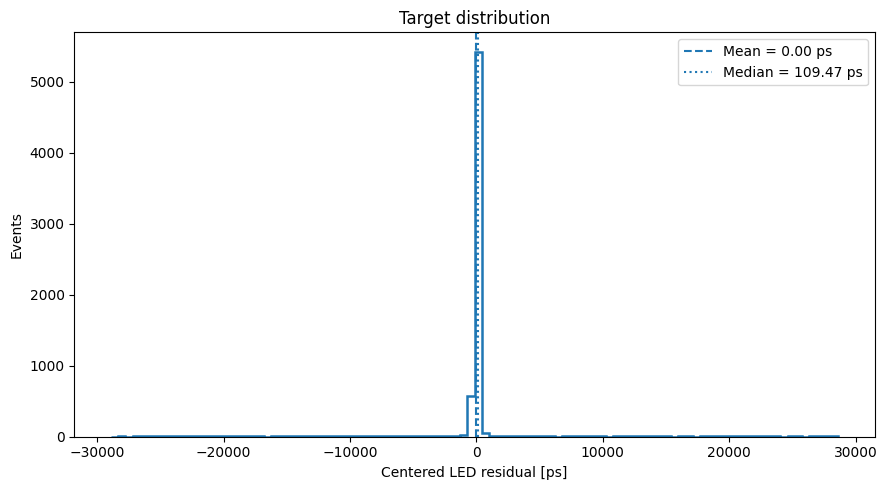

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    y,
    bins=100,
    histtype="step",
    linewidth=1.8,
)

ax.axvline(
    y.mean(),
    linestyle="--",
    linewidth=1.5,
    label=f"Mean = {y.mean():.2f} ps",
)

ax.axvline(
    y.median(),
    linestyle=":",
    linewidth=1.5,
    label=f"Median = {y.median():.2f} ps",
)

ax.set_xlabel("Centered LED residual [ps]")
ax.set_ylabel("Events")
ax.set_title("Target distribution")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------------
# Target outlier rejection using standard z-score and MAD distance
# ------------------------------------------------------------------

Z_THRESHOLD = 3.0
MAD_THRESHOLD =5.0

# Available options:
#   "zscore" -> reject using only standard z-score
#   "mad"    -> reject using only robust MAD distance
#   "either" -> reject if either criterion identifies the event
#   "both"   -> reject only if both criteria identify the event
OUTLIER_METHOD = "mad"

target_values = analysis_df[TARGET_COLUMN].astype(float)

# ------------------------------------------------------------------
# Standard z-score
# ------------------------------------------------------------------

target_mean = target_values.mean()
target_std = target_values.std(ddof=1)

print("target_mean",target_mean,"target_std",target_std)

if not np.isfinite(target_std) or target_std <= 0:
    raise ValueError(
        "Cannot calculate target z-scores because the target "
        "standard deviation is zero or invalid."
    )

standard_z_score = (
    target_values - target_mean
) / target_std

zscore_outlier_mask = (
    standard_z_score.abs() > Z_THRESHOLD
)

# ------------------------------------------------------------------
# Robust MAD distance
# ------------------------------------------------------------------

target_median = target_values.median()

target_mad = np.median(
    np.abs(target_values - target_median)
)

# 1.4826 converts MAD to a standard-deviation-equivalent scale
# for an approximately Gaussian distribution.
robust_scale = 1.4826 * target_mad

if not np.isfinite(robust_scale) or robust_scale <= 0:
    print(
        "Warning: target MAD is zero or invalid. "
        "MAD rejection will not remove any event."
    )

    mad_distance = pd.Series(
        np.zeros(len(target_values)),
        index=target_values.index,
        dtype=float,
    )

    mad_outlier_mask = pd.Series(
        False,
        index=target_values.index,
    )

else:
    mad_distance = (
        np.abs(target_values - target_median)
        / robust_scale
    )

    mad_outlier_mask = (
        mad_distance > MAD_THRESHOLD
    )

# ------------------------------------------------------------------
# Combine criteria
# ------------------------------------------------------------------

if OUTLIER_METHOD == "zscore":
    target_outlier_mask = zscore_outlier_mask

elif OUTLIER_METHOD == "mad":
    target_outlier_mask = mad_outlier_mask

elif OUTLIER_METHOD == "either":
    target_outlier_mask = (
        zscore_outlier_mask | mad_outlier_mask
    )

elif OUTLIER_METHOD == "both":
    target_outlier_mask = (
        zscore_outlier_mask & mad_outlier_mask
    )

else:
    raise ValueError(
        "OUTLIER_METHOD must be one of: "
        "'zscore', 'mad', 'either', 'both'."
    )

target_inlier_mask = ~target_outlier_mask

# Keep a copy for diagnostics.
analysis_df_before_target_filter = analysis_df.copy()

# Add diagnostic columns only to the diagnostic dataframe.
analysis_df_before_target_filter["target_z_score"] = (
    standard_z_score
)

analysis_df_before_target_filter["target_mad_distance"] = (
    mad_distance
)

analysis_df_before_target_filter["target_is_outlier"] = (
    target_outlier_mask
)

number_before = len(analysis_df)
number_removed = int(target_outlier_mask.sum())
number_after = int(target_inlier_mask.sum())

print("Target outlier rejection")
print("------------------------")
print(f"Method:                {OUTLIER_METHOD}")
print(f"Standard-z threshold:  {Z_THRESHOLD}")
print(f"MAD-distance threshold:{MAD_THRESHOLD}")
print()
print(f"Target mean:           {target_mean:.4f} ps")
print(f"Target standard dev.:  {target_std:.4f} ps")
print(f"Target median:         {target_median:.4f} ps")
print(f"Target MAD:            {target_mad:.4f} ps")
print(f"Robust scale:          {robust_scale:.4f} ps")
print()
print(f"Events before:         {number_before:,}")
print(
    f"Standard-z outliers:   "
    f"{int(zscore_outlier_mask.sum()):,}"
)
print(
    f"MAD-distance outliers: "
    f"{int(mad_outlier_mask.sum()):,}"
)
print(f"Events removed:        {number_removed:,}")
print(f"Events retained:       {number_after:,}")
print(
    f"Retained fraction:     "
    f"{100 * number_after / number_before:.3f}%"
)

# Apply the filter.
analysis_df = (
    analysis_df.loc[target_inlier_mask]
    .reset_index(drop=True)
)

# Recreate X and y after filtering.
X = analysis_df[feature_columns].copy()
y = analysis_df[TARGET_COLUMN].astype(float).copy()

print()
print(f"Final X shape: {X.shape}")
print(f"Final y shape: {y.shape}")

target_mean 7.561119848468524e-14 target_std 5213.891960466623
Target outlier rejection
------------------------
Method:                zscore
Standard-z threshold:  3.0
MAD-distance threshold:7.0

Target mean:           0.0000 ps
Target standard dev.:  5213.8920 ps
Target median:         109.4726 ps
Target MAD:            27.7070 ps
Robust scale:          41.0784 ps

Events before:         6,736
Standard-z outliers:   309
MAD-distance outliers: 1,139
Events removed:        309
Events retained:       6,427
Retained fraction:     95.413%

Final X shape: (6427, 28)
Final y shape: (6427,)


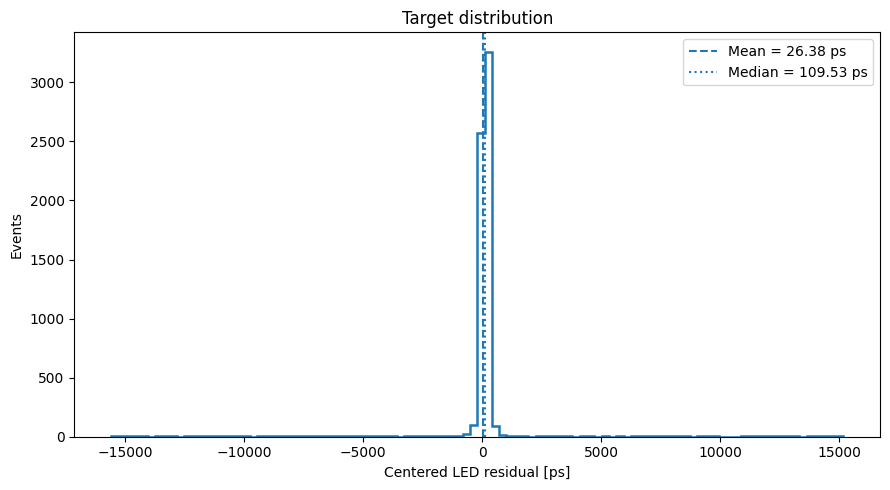

In [39]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    y,
    bins=100,
    histtype="step",
    linewidth=1.8,
)

ax.axvline(
    y.mean(),
    linestyle="--",
    linewidth=1.5,
    label=f"Mean = {y.mean():.2f} ps",
)

ax.axvline(
    y.median(),
    linestyle=":",
    linewidth=1.5,
    label=f"Median = {y.median():.2f} ps",
)

ax.set_xlabel("Centered LED residual [ps]")
ax.set_ylabel("Events")
ax.set_title("Target distribution")
ax.legend()

plt.tight_layout()
plt.show()